#### Load packages, set home directory

In [1]:
def mask_to_catchment(cube, catchment):

    catchment_proj = catchment.to_crs(epsg=27700)
    
    # Extract coordinates
    x = cube.coord('projection_x_coordinate').points
    y = cube.coord('projection_y_coordinate').points
    
    # Create 2D meshgrid of coordinates
    xx, yy = np.meshgrid(x, y)
    
    # Flatten coordinates
    points = np.vstack((xx.ravel(), yy.ravel())).T
    
    # Get catchment geometry
    catchment_geom = catchment_proj.geometry.iloc[0]
    
    # Test which grid cells are inside catchment
    mask = np.array([catchment_geom.contains(Point(pt)) for pt in points])
    
    # Reshape to grid
    mask = mask.reshape(len(y), len(x))
    return mask

# Function to convert a cftime object to string
def cft_to_string(cfttime_obj):
    """
    Convert a cftime.Datetime360Day (or other CFTime) object to 'YYYY-MM-DD' string
    """
    # Handle PartialDateTime or cftime
    try:
        year = str(cfttime_obj.year)
        month = str(cfttime_obj.month).zfill(2)
        day = str(cfttime_obj.day).zfill(2)
        return f"{year}-{month}-{day}"
    except AttributeError:
        return None  # in case it's missing or invalid

In [2]:
import iris
iris.FUTURE.date_microseconds = True
import iris.plot as iplt
import iris.quickplot as qplt
import iris.coord_systems as cs
import iris.coord_categorisation as icc
import iris.analysis
import geopandas as gpd
import os
import matplotlib.pyplot as plt
import glob as sir_globington_the_file_gatherer
import pandas as pd
import numpy as np
import contextily as ctx
from shapely.geometry import Point, Polygon, box, MultiPolygon
from shapely import vectorized, contains
from shapely.ops import unary_union
from shapely import intersects
import time
import cftime
import datetime
import cartopy.crs as ccrs
from scipy.ndimage import label, generate_binary_structure
import pickle

rainfalldir ='/scratch/hydro5/users/ld14116/SDM_bias_correction/Hourly/01/'
# os.chdir(homedir)

In [3]:
yr = 1995
event_idx = 4

### Get rainfall event csvs

In [11]:
home_dir = "/scratch/hydro4/users/" # kv25483/"
ncl_events = pd.read_csv(home_dir + "la17355/FUTURE-FLOOD/UKCP_rainfall_events/fixed_threshold_30mm_with_volume/Tyne(Northumberland)_01_full_events_with_event_nums.csv")
rainfall_events_oneyr = ncl_events[ncl_events['start_year']==yr]
rainfall_events_oneyr = rainfall_events_oneyr.reset_index(drop=True)
rainfall_events_oneyr

,start_indices,stop_indices,event_durations,peaks,start_year,start_month,start_day,start_hour,start_time,stop_time,start_time_seconds,stop_time_seconds,event_vol,max_extent,acc_total,acc_3hr,acc_6hr,acc_12hr,acc_24hr,event_num
0,6829,6850,21,35.77378,1995,9,15,12,222108.5,222129.5,799590600,799666200,3123.716481,88,3123.716481,1857.6286,2773.3428,3080.3877,NaN,4


In [17]:
# # rainfall_events =pd.read_csv("/scratch/hydro4/users/ld14116/5km_grid/Rainfall_events/Events_duration_ensemble_monthly_threshold_consistent/NorthEastEngland_Ens_01_2020-2040_full_events.csv")
# rainfall_events =pd.read_csv("/scratch/hydro4/users/ld14116/5km_grid/Rainfall_events/Events_duration_ensemble_monthly_threshold_consistent/NorthEastEngland_Ens_01_1980-2000_full_events.csv")

# # Create a datetime column, coercing invalid dates to NaT
# rainfall_events['start_date'] = pd.to_datetime(
#     dict(year=rainfall_events['start_year'],month=rainfall_events['start_month'],
#         day=rainfall_events['start_day'], hour =rainfall_events['start_hour']), errors='coerce')

# rainfall_events['stop_date'] = pd.to_datetime(
#     dict(year=rainfall_events['stop_year'],month=rainfall_events['stop_month'],
#         day=rainfall_events['stop_day'], hour =rainfall_events['stop_hour']), errors='coerce')

# # Get events just for one year
# rainfall_events_oneyr = rainfall_events[rainfall_events['start_year']==yr]

# # Inspect
# rainfall_events_oneyr.head()

#### Get start and stop indices of the peak intensity relative to just this year
As it is the indices are stored relative to the full timeslice

In [18]:
# december_1980_indices = (30*24)
# yrs_before_this_yr = yr - 1981
# yrs_before_this_yr_indices = yrs_before_this_yr * 360 * 24
# correction_factor = yrs_before_this_yr_indices + december_1980_indices

In [19]:
# start_index = int(rainfall_events_oneyr.iloc[event_idx]['start_indices'])-1
# stop_index = int(rainfall_events_oneyr.iloc[event_idx]['stop_indices'])-1

# start_index = start_index - correction_factor
# stop_index = stop_index - correction_factor
# print(start_index, stop_index)

In [12]:
start_index = rainfall_events_oneyr['start_indices'][0]
stop_index = rainfall_events_oneyr['stop_indices'][0]

### Get rainfall netCDF for relevant year

In [6]:
files = []

# December previous year FIRST
files.append(f"{rainfalldir}bc_pr_rcp85_land-cpm_uk_5km_01_1hr_{yr-1}1201-{yr-1}1230.nc")

# Jan–Nov of target year
for m in range(1, 12):
    files.append(f"{rainfalldir}bc_pr_rcp85_land-cpm_uk_5km_01_1hr_{yr}{m:02d}01-{yr}{m:02d}30.nc")

monthly_cubes = iris.cube.CubeList()

for f in files:
    cube = iris.load(f)[1]
    cube.attributes = {}
    monthly_cubes.append(cube)

cube_uk_oneyr = monthly_cubes.concatenate_cube()

/home/kv25483/anaconda3/envs/futureflood/lib/python3.10/site-packages/iris/fileformats/cf.py:1475: IrisCfNonSpanningVarWarning: Ignoring variable ensemble_member_id referenced by variable pr: Dimensions ('ensemble_member', 'string27') do not span ('time', 'projection_y_coordinate', 'projection_x_coordinate')
  warnings.warn(


In [9]:
# one_timestep = cube_uk_1994[0,:,:]
# qplt.contourf(one_timestep)  # first time slice
# plt.gca().coastlines()

### Mask out cells not within Newcastle

In [7]:
catchments = gpd.read_file("/scratch/hydro4/users/kv25483/FutureFlood/Data/NewcastleExample/catchment_identifier/hyd_areas_GB_with_subcatchments.shp")
newcastle = catchments[catchments['HA_NUM'] == "23"]
catchment_poly = newcastle.geometry[60]

In [8]:
method = "full_cell"  # choose "center_point" or "full_cell"

# --- Cube coordinates ---
x = cube_uk_oneyr.coord('projection_x_coordinate').points
y = cube_uk_oneyr.coord('projection_y_coordinate').points

dx = x[1] - x[0]  # assume uniform spacing
dy = y[1] - y[0]

# Create mask
mask = np.zeros((len(y), len(x)), dtype=bool)

if method == "center_point":
    # --- Center point approach ---
    for j, yy in enumerate(y):
        for i, xx in enumerate(x):
            pt = Point(xx, yy)
            # Use contains (strict) or intersects (include boundary)
            # mask[j, i] = catchment_poly.contains(pt)
            mask[j, i] = catchment_poly.intersects(pt)

elif method == "full_cell":
    # --- Full-cell intersection (any overlap) ---
    for j, yy in enumerate(y):
        for i, xx in enumerate(x):
            cell = box(xx - dx/2, yy - dy/2, xx + dx/2, yy + dy/2)
            mask[j, i] = cell.intersects(catchment_poly)

else:
    raise ValueError("Invalid method. Choose 'center_point' or 'full_cell'.")

# --- Apply mask to cube ---
cube_catchment = cube_uk_oneyr.copy()
cube_catchment.data = np.where(mask[np.newaxis, :, :], cube_catchment.data, np.nan)

# # --- Plot for check: NB this is just the first timeslice, shouldnt correspond to later plot ---
# fig, ax = plt.subplots(figsize=(3,3), subplot_kw={'projection': ccrs.OSGB()})
# qplt.pcolormesh(cube_catchment[0], axes=ax)

# minx, miny, maxx, maxy = catchment_poly.bounds
# ax.set_extent([minx, maxx, miny, maxy], crs=ccrs.OSGB())
# newcastle.boundary.plot(ax=ax, color='black');

In [12]:
# one_month_cube = cube_catchment.extract(iris.Constraint(time=lambda cell: cell.point.month == 8))

#### Find the maximum precipitation and where it occurred

In [13]:
# Get just the part of the timeseries where it was raining
subset = cube_catchment[start_index:stop_index, :, :].data

# Find index of maximum value
# This first internally flattens the array (e.g., subset.flatten(), so flattened length = 18 × 140 × 120)
# flat_undex is the nth item in that flattened array
flat_index = np.nanargmax(subset)

# Convert to (time, x, y) indices
# np.unravel_index converts a flat index back into the multi-dimensional indices.
# t_local is the timestep within the event
t_local, y_idx, x_idx = np.unravel_index(flat_index, subset.shape)

# Actual precipitation value
max_precip = subset[t_local, y_idx, x_idx]

# convert time index back to original cube index
# t_global is the timestep of the maximum within the whole event
t_global = t_local + start_index

# Find coordinates of peak cell
x_coord = cube_uk_oneyr.coord('projection_x_coordinate').points[x_idx]
y_coord = cube_uk_oneyr.coord('projection_y_coordinate').points[y_idx]

print("Max precipitation:", max_precip)
print("Time index:", t_global)
print("Grid cell indices (x,y):", x_idx, y_idx)
print("Grid cell coordinates (easting, northing):", x_coord, y_coord)

Max precipitation: 35.773785
Time index: 6840
Grid cell indices (x,y): 119 125
Grid cell coordinates (easting, northing): 397500.0 592500.0


#### Find the temporal profile of the event at the grid cell with the maximum

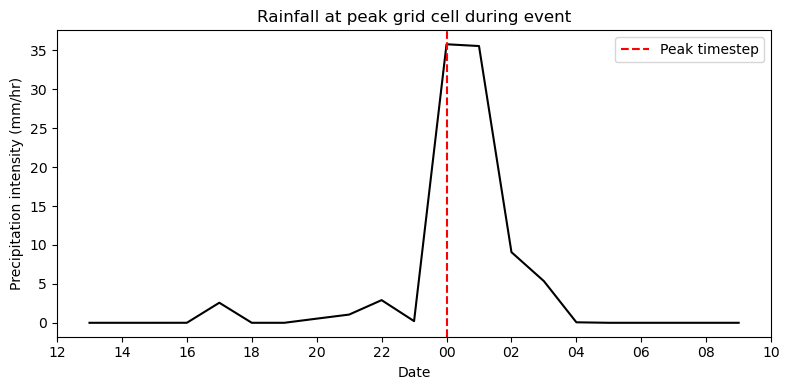

In [14]:
# Extract event time series
ts = cube_catchment[start_index:stop_index, y_idx, x_idx]

times = ts.coord('yyyymmddhh').points.astype(int)
values = ts.data

# Convert to datetime
dt = pd.to_datetime(times.astype(str), format="%Y%m%d%H")

# Plot
plt.figure(figsize=(8,4))
plt.plot(dt, values, color='black')

# Mark peak timestep
rainfall_peak_time = cube_catchment.coord('yyyymmddhh').points[t_global]
peak_dt = pd.to_datetime(str(int(rainfall_peak_time)), format="%Y%m%d%H")
plt.axvline(peak_dt, linestyle='--', color = 'red', label='Peak timestep')

# Format ticks
plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%H'))

plt.xlabel("Date")
plt.ylabel("Precipitation intensity (mm/hr)")
plt.title("Rainfall at peak grid cell during event")
plt.legend()

plt.tight_layout()
plt.show()

#### Find the spatial profile of the event at the timestep of the maximum

In [15]:
threshold_level = 0.3
diagonal = True

In [49]:
# # 'threshold' = all cells above threshold, 'cluster' = only connected cluster
# mode = 'cluster'  # <--- change this to 'threshold' or 'cluster'

# fig, ax = plt.subplots(figsize=(6,6), subplot_kw={'projection': ccrs.OSGB()})

# # --- Extract timestep cube ---
# peak_slice = cube_catchment[t_global, :, :]

# # --- Base rainfall field ---
# qplt.pcolormesh(peak_slice, axes=ax, cmap='Blues')
# rain = peak_slice.data
# peak_value = rain[y_idx, x_idx]
# threshold = threshold_level * peak_value
# mask = rain >= threshold

# # --- Grid coordinates ---
# x = peak_slice.coord('projection_x_coordinate').points
# y = peak_slice.coord('projection_y_coordinate').points
# dx = x[1] - x[0]
# dy = y[1] - y[0]

# # --- 10km radius sum around peak cell ---
# radius_m = 10000  # 10km in metres
# peak_x_coord = x[x_idx]
# peak_y_coord = y[y_idx]

# # Distance from every grid cell centre to the peak cell
# xx, yy = np.meshgrid(x, y)
# distance_from_peak = np.sqrt((xx - peak_x_coord)**2 + (yy - peak_y_coord)**2)

# # Mask cells within radius and sum rainfall
# radius_mask = distance_from_peak <= radius_m
# total_rainfall_in_radius = np.sum(rain[radius_mask])
# cell_area_km2 = 25  # 5x5km grid
# n_cells_in_radius = np.sum(radius_mask)
# print(f"Cells within 10km radius: {n_cells_in_radius} ({n_cells_in_radius * cell_area_km2} km²)")
# print(f"Sum of rainfall within 10km radius: {total_rainfall_in_radius:.2f}")

# # --- Draw 10km radius circle on plot ---
# circle = Point(peak_x_coord, peak_y_coord).buffer(radius_m)
# xs_circ, ys_circ = circle.exterior.xy
# ax.plot(xs_circ, ys_circ, color='black', linewidth=1.5, 
#         linestyle='--', transform=ccrs.OSGB(), label='10km radius')

# # --- Build the mask depending on mode ---
# if mode == 'threshold':
#     ys_mask, xs_mask = np.where(mask)
#     outline_colour = 'cyan'

# elif mode == 'cluster':
#     if diagonal == False:
#         labeled, num_features = label(mask)
#     else:
#         structure = generate_binary_structure(2, 2)
#         labeled, num_features = label(mask, structure=structure)
#     peak_label = labeled[y_idx, x_idx]
#     cluster_mask = (labeled == peak_label)
#     cluster_size = np.sum(cluster_mask) - 1
#     print(f"Connected cells >{int(threshold_level*100)}% of peak: {cluster_size}")
#     ys_mask, xs_mask = np.where(cluster_mask)
#     outline_colour = 'orange'

# # --- Create a square polygon for each grid cell ---
# cells = [box(x[xi]-dx/2, y[yi]-dy/2, x[xi]+dx/2, y[yi]+dy/2)
#          for yi, xi in zip(ys_mask, xs_mask)]

# # --- Merge cells and plot outline ---
# storm_shape = unary_union(cells)
# polygons = storm_shape.geoms if isinstance(storm_shape, MultiPolygon) else [storm_shape]

# for poly in polygons:
#     xs_poly, ys_poly = poly.exterior.xy
#     ax.plot(xs_poly, ys_poly, color=outline_colour, linewidth=2, transform=ccrs.OSGB())

# # --- Plot peak grid cell ---
# ax.scatter(peak_x_coord, peak_y_coord, color='red', s=20, 
#            transform=ccrs.OSGB(), label='Peak cell')

# # --- Catchment extent with buffer ---
# buffer = 2000
# minx, miny, maxx, maxy = catchment_poly.bounds
# ax.set_extent([minx-buffer, maxx+buffer, miny-buffer, maxy+buffer], crs=ccrs.OSGB())

# # --- Catchment boundary ---
# newcastle.boundary.plot(ax=ax, color='black')

# plt.title(f'Mode: {mode} | Threshold: {threshold_level*100:.0f}% of peak\n'
#           f'10km radius sum: {total_rainfall_in_radius:.2f} | Cells in radius: {n_cells_in_radius}')
# ax.legend(loc='upper right', fontsize=7)
# plt.show()

In [16]:
def analyse_peak_event(cube_catchment, t_global, y_idx, x_idx, 
                        threshold_level, diagonal=True, 
                        neighbourhood_size=1):
    """
    Analyse a single peak rainfall event.
    
    Parameters
    ----------
    cube_catchment    : Iris cube, dims [time, y, x]
    t_global          : int, timestep index of peak
    y_idx, x_idx      : int, grid indices of peak cell
    threshold_level   : float, e.g. 0.25 for 25% of peak
    diagonal          : bool, use diagonal connectivity for clustering
    neighbourhood_size: int, number of steps out for neighbourhood sum
                        (1 = 3x3, 2 = 5x5, etc.)
    
    Returns
    -------
    dict of metrics
    """
    peak_slice = cube_catchment[t_global, :, :]
    rain = peak_slice.data
    peak_value = rain[y_idx, x_idx]
    threshold = threshold_level * peak_value

    x = peak_slice.coord('projection_x_coordinate').points
    y = peak_slice.coord('projection_y_coordinate').points
    dx = x[1] - x[0]  # cell size in metres

    # --- Threshold mask ---
    mask = rain >= threshold
    total_above_threshold = int(np.sum(mask))

    # --- Connected cluster ---
    if not diagonal:
        labeled, num_features = label(mask)
    else:
        structure = generate_binary_structure(2, 2)
        labeled, num_features = label(mask, structure=structure)
    peak_label = labeled[y_idx, x_idx]
    cluster_mask = (labeled == peak_label)
    cluster_size = int(np.sum(cluster_mask)) - 1  # exclude peak cell

    # --- Neighbourhood sum ---
    n = neighbourhood_size
    y_min = max(0, y_idx - n)
    y_max = min(rain.shape[0], y_idx + n + 1)
    x_min = max(0, x_idx - n)
    x_max = min(rain.shape[1], x_idx + n + 1)
    neighbourhood = rain[y_min:y_max, x_min:x_max]
    neighbourhood_sum = float(np.sum(neighbourhood))
    neighbourhood_sum = float(np.sum(neighbourhood)) - float(peak_value)
    neighbourhood_cells = neighbourhood.size

    return {
        't_global'              : t_global,
        'y_idx'                 : y_idx,
        'x_idx'                 : x_idx,
        'peak_x_coord'          : float(x[x_idx]),
        'peak_y_coord'          : float(y[y_idx]),
        'peak_value'            : float(peak_value),
        'threshold_level'       : threshold_level,
        'threshold_value'       : float(threshold),
        'total_above_threshold' : total_above_threshold,
        'cluster_size'          : cluster_size,
        'neighbourhood_size'    : neighbourhood_size,
        'neighbourhood_cells'   : neighbourhood_cells,
        'neighbourhood_sum'     : neighbourhood_sum,
    }


def plot_peak_event(cube_catchment, t_global, y_idx, x_idx,
                    threshold_level, diagonal=True, catchment_poly=None,
                    boundary_gdf=None):
    """
    Plot threshold and cluster outlines side by side for a single event.
    """
    peak_slice = cube_catchment[t_global, :, :]
    rain = peak_slice.data
    peak_value = rain[y_idx, x_idx]
    threshold = threshold_level * peak_value
    mask = rain >= threshold

    x = peak_slice.coord('projection_x_coordinate').points
    y = peak_slice.coord('projection_y_coordinate').points
    dx = x[1] - x[0]
    dy = y[1] - y[0]

    # --- Connected cluster ---
    if not diagonal:
        labeled, _ = label(mask)
    else:
        structure = generate_binary_structure(2, 2)
        labeled, _ = label(mask, structure=structure)
    peak_label = labeled[y_idx, x_idx]
    cluster_mask = (labeled == peak_label)

    def make_outline(bool_mask):
        ys_m, xs_m = np.where(bool_mask)
        cells = [box(x[xi]-dx/2, y[yi]-dy/2, x[xi]+dx/2, y[yi]+dy/2)
                 for yi, xi in zip(ys_m, xs_m)]
        shape = unary_union(cells)
        return shape.geoms if isinstance(shape, MultiPolygon) else [shape]

    threshold_polys = make_outline(mask)
    cluster_polys   = make_outline(cluster_mask)

    fig, axes = plt.subplots(1, 2, figsize=(12, 6),
                             subplot_kw={'projection': ccrs.OSGB()})

    for ax, polys, colour, title in zip(
        axes,
        [threshold_polys, cluster_polys],
        ['darkgreen', 'orange'],
        [f'All cells above threshold ({threshold_level*100:.0f}% of peak)',
         f'Connected cluster only ({threshold_level*100:.0f}% of peak)']
    ):
        qplt.pcolormesh(peak_slice, axes=ax, cmap='Blues')

        for poly in polys:
            xs_p, ys_p = poly.exterior.xy
            ax.plot(xs_p, ys_p, color=colour, linewidth=3.5, transform=ccrs.OSGB())

        ax.scatter(x[x_idx], y[y_idx], color='red', s=20,
                   transform=ccrs.OSGB(), zorder=5)

        if catchment_poly is not None:
            buffer = 2000
            minx, miny, maxx, maxy = catchment_poly.bounds
            ax.set_extent([minx-buffer, maxx+buffer,
                           miny-buffer, maxy+buffer], crs=ccrs.OSGB())

        if boundary_gdf is not None:
            boundary_gdf.boundary.plot(ax=ax, color='black')

        ax.set_title(title)

    plt.suptitle(f'Peak value: {peak_value:.2f} | Timestep: {t_global}')
    plt.tight_layout()
    plt.show()

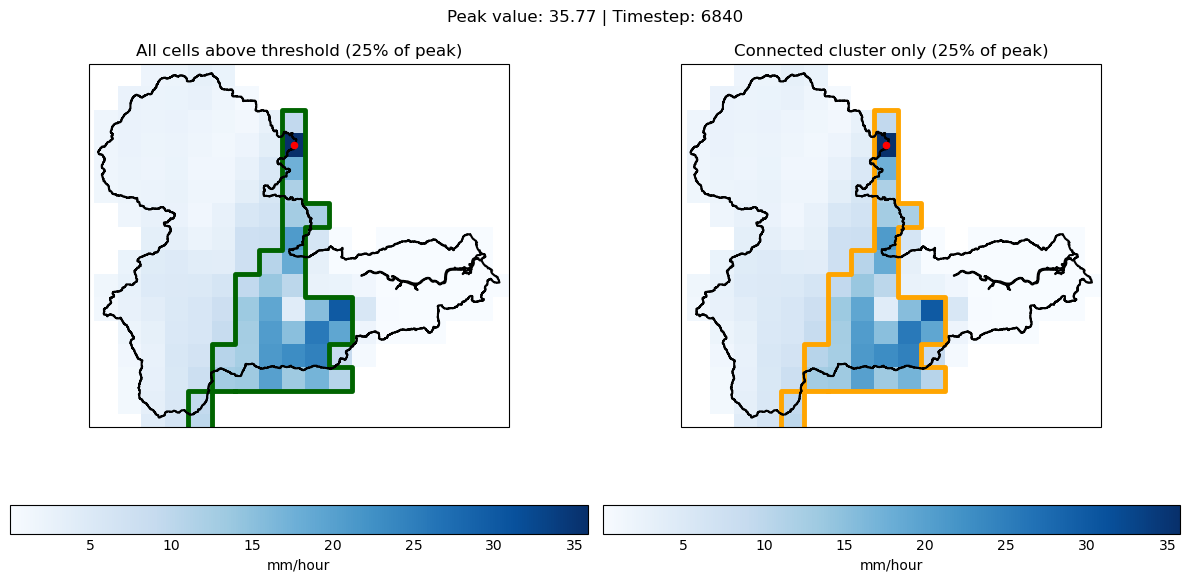

In [17]:
# Define your events — each is a dict of kwargs for analyse_peak_event
events = [
    dict(t_global=t_global, y_idx=y_idx, x_idx=x_idx, threshold_level=0.25),
#     dict(t_global=t2, y_idx=y2, x_idx=x2, threshold_level=0.25),
]

results = [analyse_peak_event(cube_catchment, **e) for e in events]
results_df = pd.DataFrame(results)

# Plot a specific event
plot_peak_event(cube_catchment, t_global=t_global, y_idx=y_idx, x_idx=x_idx,
                threshold_level=0.25, catchment_poly=catchment_poly,
                boundary_gdf=newcastle)

## Find soil moisture beneath the peak

Get one year soil moisture data

In [26]:
sm_dir = '/scratch/hydro4/shared_data/climate_projections/UKCP18/UKCP_local/Soil_moisture/5km_regridded/Ens_01/'
sm_one_yr = iris.load(sm_dir + f'r001i1p00000_{yr-1}1201-{yr}1130_mrso.nc')[0]

Get soil moisture just at the cell which had the peak value

In [27]:
sm_one_yr_at_max_cell = sm_one_yr[:, y_idx, x_idx]

Get the day of the peak rainfall event as a cftime.Datetime360Day object

In [28]:
time_coord = cube_catchment.coord('time')
t = time_coord.units.num2date(time_coord.points[t_global])
rainfall_peak_day = cftime.Datetime360Day(t.year, t.month, t.day)

Get the day of the rainfall event starting/stopping as a cftime.Datetime360Day object

In [29]:
rainfall_start_t = time_coord.units.num2date(time_coord.points[start_index])
rainfall_start_day = cftime.Datetime360Day(rainfall_start_t.year, rainfall_start_t.month, rainfall_start_t.day)

rainfall_stop_t = time_coord.units.num2date(time_coord.points[stop_index])
rainfall_stop_day = cftime.Datetime360Day(rainfall_stop_t.year, rainfall_stop_t.month, rainfall_stop_t.day)

Get soil moisture X days before and after rainfall peak at the peak grid cell

In [30]:
delta = datetime.timedelta(days=10)

start_time = rainfall_peak_day - delta
end_time = rainfall_peak_day + delta

subset = sm_one_yr_at_max_cell.extract(iris.Constraint(time=lambda t: start_time <= t.point <= end_time))

Create daily version of rainfall grid

In [31]:
# --- Rainfall at peak grid cell ---
rain_cell = cube_catchment[:, y_idx, x_idx]

# Add year/day_of_year coords for aggregation
icc.add_day_of_year(rain_cell, 'time')

# Aggregate to daily means
rain_daily = rain_cell.aggregated_by(['year','day_of_year'], iris.analysis.MEAN)

Get rainfall at peak grid cell before and after peak

In [32]:
# Extract 10 days before and after event
delta = datetime.timedelta(days=10)
window_start = rainfall_start_day - delta
window_end   = rainfall_stop_day + delta
rain_window = rain_daily.extract(iris.Constraint(time=lambda t: window_start <= t.point <= window_end))
rain_times = rain_window.coord('time').units.num2date(rain_window.coord('time').points)
rain_times_str = [t.strftime('%Y-%m-%d') for t in rain_times]
rain_values = rain_window.data

Plot

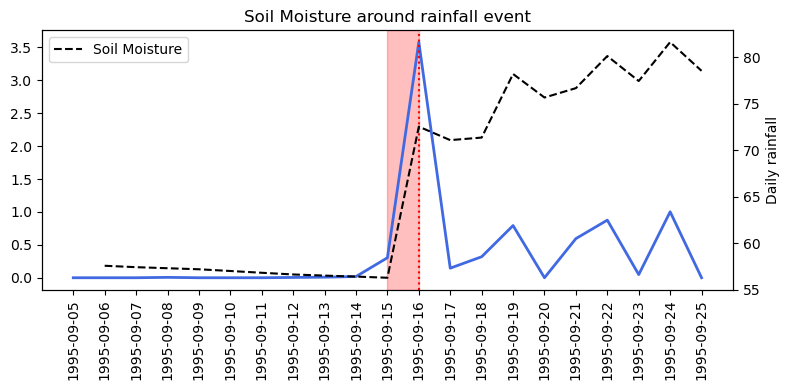

In [33]:
fig,ax1=plt.subplots(figsize=(8,4))

# Get formatted times
peak_str = rainfall_peak_day.strftime('%Y-%m-%d')
start_str = rainfall_start_day.strftime('%Y-%m-%d')
end_str = rainfall_stop_day.strftime('%Y-%m-%d')

# ------- Plot rainfall data (axis 1) -------
mask = ~np.isnan(rain_values)
ax1.plot(np.array(rain_times_str)[mask], rain_values[mask], linewidth=2, color='royalblue', label='Daily rainfall (peak cell)')

# Plot time of peak, and start and stop of event
ax1.axvline(peak_str, color='red', linestyle="dotted", label="Rainfall peak")
ax1.axvspan(start_str, end_str, color="red", alpha=0.25, label="Rainfall event")

ax1.tick_params(axis='x', rotation=90)

# ------- Plot soil moisture data (axis 2) -------
# Create secondary y-axis
ax2 = ax1.twinx()

# Get time values formatted for plotting
time_coord = subset.coord('time')
times = time_coord.units.num2date(time_coord.points)
times_str = [t.strftime('%Y-%m-%d') for t in times]
# Get 1D data array
values = subset.data

# Plot rainfall data
ax2.plot(times_str, values, color='black', linestyle='dashed', label="Soil Moisture")

ax2.set_ylabel("Soil Moisture")
ax2.set_title("Soil Moisture around rainfall event")

ax2.set_ylabel("Daily rainfall") 

plt.legend()
plt.tight_layout()
plt.show()

### Find mean soil moisture at that grid cell 1/3/5 days before peak 

In [34]:
n_days_ls = [2,3,4,5]
mean_sm_ls = []
for n_days in n_days_ls:
    delta = datetime.timedelta(days=n_days)
    start_time = rainfall_peak_day - delta
    end_time = rainfall_peak_day  # exclusive of the peak day itself

    # Subset using both bounds
    subset = sm_one_yr_at_max_cell.extract(
        iris.Constraint(time=lambda cell: start_time <= cell.point < end_time))

    # Compute mean soil moisture over those 3 days
    if n_days == 1:
        mean_sm = subset.data
    else:
        mean_sm = subset.collapsed('time', iris.analysis.MEAN)

    mean_sm_ls.append(mean_sm.data)

In [36]:
sm_one_yr

<iris 'Cube' of moisture_content_of_soil_layer / (kg m-2) (time: 360; projection_y_coordinate: 244; projection_x_coordinate: 180)>

## Flood outcomes below the peak

In [41]:
iris.FUTURE.datum_support = True

In [64]:
event_num = rainfall_events_oneyr['event_num'][0]
event_num=30

In [65]:
# flood_dir = '/scratch/hydro5/users/la17355/FUTURE-FLOOD/Results/Pluvial/v4/5km_total/'
# flood_one_yr = iris.load(flood_dir+ f'r001i1p00000_{yr-1}1201-{yr}1130_mrso.nc')[0]
# flood_one_yr_at_max_cell = sm_one_yr[:, y_idx, x_idx]
# flood_one_yr_at_max_cell
os.listdir("/scratch/hydro5/users/la17355/FUTURE-FLOOD/Results/Pluvial/v4/5km_total/Ens01_23/10cm/")
flood_area = iris.load("/scratch/hydro5/users/la17355/FUTURE-FLOOD/Results/Pluvial/v4/5km_total/Ens01_23/10cm/flooded_volume_5km_total_Ens01_23_10cm.nc")[0]
flood_area_one_event = flood_area[event_num]
flood_area_one_event

<iris 'Cube' of Total flooded volume per 5km grid cell / (m3) (projection_y_coordinate: 244; projection_x_coordinate: 180)>

In [63]:
iris.load("/scratch/hydro5/users/la17355/FUTURE-FLOOD/Results/Pluvial/v4/5km_total/Ens01_23/10cm/flooded_volume_5km_total_Ens01_23_10cm.nc")[0]

<iris 'Cube' of Total flooded volume per 5km grid cell / (m3) (event number: 95; projection_y_coordinate: 244; projection_x_coordinate: 180)>

In [72]:
flood_area_one_event.coord('projection_x_coordinate').guess_bounds()
flood_area_one_event.coord('projection_y_coordinate').guess_bounds()
bng = OSGB()
flood_area_one_event.coord('projection_x_coordinate').coord_system = bng
flood_area_one_event.coord('projection_y_coordinate').coord_system = bng

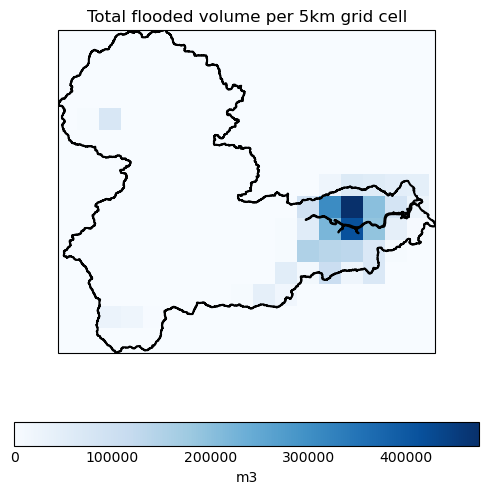

In [73]:
import iris
from iris.coord_systems import OSGB

# Reassign the correct British National Grid coord system
# bng = OSGB()
# flood_area_one_event.coord('projection_x_coordinate').coord_system = bng
# flood_area_one_event.coord('projection_y_coordinate').coord_system = bng

# iplt.pcolormesh(flood_area_one_event)

# --- Plot for check: NB this is just the first timeslice, shouldnt correspond to later plot ---
fig, ax = plt.subplots(figsize=(6,6), subplot_kw={'projection': ccrs.OSGB()})
qplt.pcolormesh(flood_area_one_event, axes=ax, cmap = 'Blues')

minx, miny, maxx, maxy = catchment_poly.bounds
ax.set_extent([minx, maxx, miny, maxy], crs=ccrs.OSGB())
newcastle.boundary.plot(ax=ax, color='black');

# plt.colorbar()
# plt.show()